In [ ]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import os
import glob
import joblib
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings('ignore')

In [32]:
#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import joblib

import torch 
import torch.nn as nn

In [33]:
df = pd.read_csv("Post_EDA_data.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,y
0,12000.0,12000.0,12000.0,36 months,7.97%,375.88,A,A5,10+ years,OWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
1,32000.0,32000.0,32000.0,36 months,11.99%,1062.71,B,B5,10+ years,MORTGAGE,...,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N,1
2,40000.0,40000.0,40000.0,60 months,15.05%,952.65,C,C4,9 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
3,16000.0,16000.0,16000.0,36 months,7.97%,501.17,A,A5,5 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
4,33000.0,33000.0,33000.0,36 months,7.21%,1022.12,A,A3,< 1 year,MORTGAGE,...,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N,0


In [34]:
df.shape

(2029952, 131)

In [35]:
class Feature_engineering_step(BaseEstimator,TransformerMixin):
    def __init__(self,date_cols):
        self.date_cols = date_cols


    def fit(self,X,y=None):
        X= X.copy()

        # Make sure date columns are actually datetime
        for col in self.date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        self.current_t_ = X[self.date_cols].max().max()
        return self
    
    def transform(self,X):
        X = X.copy()

        for col in self.date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        X["customer_history"] = (X['issue_d'] - X["earliest_cr_line"]).dt.days
        X["months_since_earliest_credit_line"] = (
            (self.current_t_.year - X["earliest_cr_line"].dt.year) * 12
            + (self.current_t_.month - X["earliest_cr_line"].dt.month)
        )

        X["loan_age_months"] = ((self.current_t_.year - X["issue_d"].dt.year) * 12
                                + (self.current_t_.month - X["issue_d"].dt.month))
        
        X["current_balance_ratio"] = (
            X["out_prncp"] / X["loan_amnt"].replace(0, np.nan)
        )

        X["payment_progress_ratio"] = (
            X["total_rec_prncp"] / X["loan_amnt"].replace(0, np.nan)
        )

        X = X.drop(columns=self.date_cols)

        X["term_months"] = X["term"].str.extract("(\d+)").astype(float)

        emp_length_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
    }

        X["emp_length_num"] = X["emp_length"].map(emp_length_map)

        X["int_rate"] = X["int_rate"].astype(str).str.replace("%", "", regex=False).astype(float)
        X["revol_util"] = X["revol_util"].astype(str).str.replace("%", "", regex=False).astype(float)

        # Drop original text versions
        X = X.drop(columns=["term", "emp_length"])


        return X


In [36]:
date_cols = ["issue_d", "last_pymnt_d", "last_credit_pull_d", "next_pymnt_d", "earliest_cr_line"]

In [37]:
#self.Q1_ saves the learned threshold from training so it can be consistently applied to new data.
class OutlierFlaggerv2(BaseEstimator, TransformerMixin):
    #Sklearn pipeline uses both x and y so thus we add y=None
    def fit(self,X, y=None):
        #To keep track of the columns
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        self.feature_names_in_ = list(X.columns)
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        #Return the capsulated info obtained
        return self

    def transform(self,X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        X.columns = X.columns.astype(str)
        lower = self.Q1 -  1.5*self.IQR
        upper = self.Q3 +  1.5*self.IQR
        flags = ((X < lower) |(X>upper)).astype(int)
        #We keep the original feature and add a new column to capture outlier information, not replace it.

        flags.columns = [str(col) + "_outlier" for col in X.columns]
        
        return flags
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            #Store the input features in a variable, then to a list
            input_features = self.feature_names_in_
        input_features = [str(col) for col in input_features]
        outlier_names = [col + "_outlier" for col in input_features]
        return np.array(outlier_names, dtype=object)

In [38]:
class Missing_val_dropper(BaseEstimator,TransformerMixin):
    def __init__(self, threshold = 50.0):
        self.threshold = threshold

    def fit(self,X,y=None):
        #learns the columns to drop
        X = pd.DataFrame(X).copy()

        #Missing percent vector that holds the missing percentage indexed by the col names
        missing_percent = X.isna().mean() * 100

        #Columns with  >= threshold missigness
        self.columns_to_drop = missing_percent[missing_percent >= self.threshold].index.tolist()

        self.feature_names = X.columns.tolist()
        return self
    
    def transform(self,X):
        #actually drops the columns
        X = pd.DataFrame(X).copy()
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array([
            col for col in input_features
            if col not in self.columns_to_drop
        ])

## Cross Validation

In [39]:
#Divide from X and y
X = df.drop("y", axis=1)
y= df["y"]

In [40]:
#Dropped after seeing it was data leakage
X.drop(["recoveries","collection_recovery_fee"],axis=1, inplace=True)
#recoveries is the money recovered after a loan has defaulted.
#collection_recovery_fee is the cost charged for collecting that recovered money.


In [41]:
leakage_cols = [
    "out_prncp_inv",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "debt_settlement_flag",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int"
]
X.drop(leakage_cols,axis=1,inplace=True)

In [42]:
#Hardship flag removal since it indicates if the borrower is haviung trouble paying
X.drop("hardship_flag",axis=1,inplace=True)

In [43]:
#subsample a subset of the data
X_sub = X.sample(n=200000, random_state=42)
y_sub = y.loc[X_sub.index]

In [44]:
# train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub,
    test_size=0.30,
    random_state=42,
    stratify=y_sub
)

#validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

'''
Ideally we end up with
70% train
15% validation
15% test
'''

'\nIdeally we end up with\n70% train\n15% validation\n15% test\n'

In [45]:
X_train.shape

(140000, 120)

In [46]:
X_val.shape

(30000, 120)

In [47]:
numerical_columns = X.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns = X.select_dtypes(include=["object","category"]).columns

In [48]:
#Sample the numerical columns only from the training data
X_sample = X_train.sample(n=5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

In [49]:
#Only numerical columns
X_num_sample = X_sample[numerical_columns]
X_num_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
1308177,5000.0,5000.0,5000.0,179.69,20000.0,35.29,0.0,735.0,739.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690673,37600.0,37600.0,37600.0,1164.60,325000.0,12.62,1.0,770.0,774.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568761,9000.0,9000.0,9000.0,290.75,33000.0,27.71,0.0,675.0,679.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1425531,28000.0,28000.0,27900.0,658.21,121400.0,5.07,0.0,755.0,759.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1588854,28000.0,28000.0,28000.0,780.52,110000.0,14.87,5.0,665.0,669.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
fe = Feature_engineering_step(date_cols=date_cols)

X_train_fe = fe.fit_transform(X_train)
X_val_fe = fe.transform(X_val)
X_test_fe = fe.transform(X_test)

In [51]:
#X_train_fe.to_csv("X_train_fe.csv", index=False)
#X_val_fe.to_csv("X_val_fe.csv", index=False)
#X_test_fe.to_csv("X_test_fe.csv", index= False)

In [52]:
#y_train.to_csv("y_train.csv", index=False)
#y_val.to_csv("y_val.csv", index=False)
#y_test.to_csv("y_test.csv", index= False)

In [53]:
numerical_columns_train_recalculated = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

Cat_columns_train_recaulciated = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()

## PCA & t-nse

In [54]:
#Consruct the numerical pipeline and fit transform
#Try standard scaler and Robust
num_only_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler())
])

X_num_processed = num_only_pipe.fit_transform(X_num_sample)

In [55]:
#Do PCA on the trimmed data
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_num_processed)

In [56]:
#Apply t-nse
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

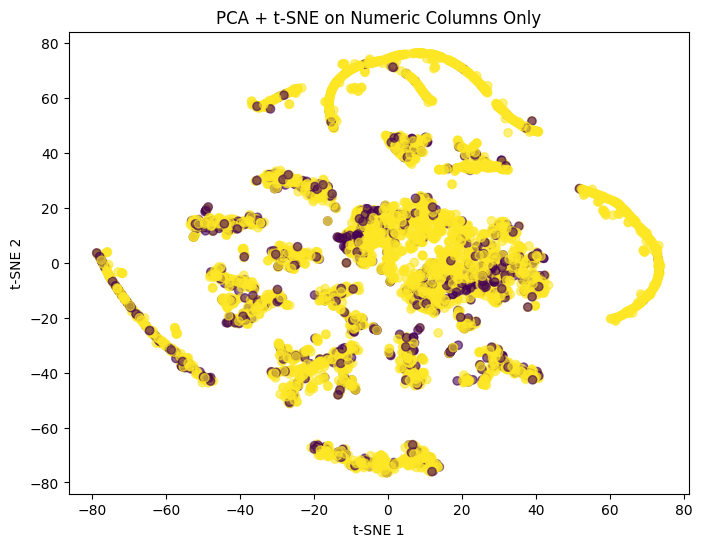

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, alpha=0.6)
plt.title("PCA + t-SNE on Numeric Columns Only")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## ---------------------------

## Pipeline creation & post-transformation evaluation & Univariate variable selection

Block of code below assesses the multicollinearity between 2 numerical independent variables. If it is above a certain threshold we remove the one with less mutual information

In [58]:
#Version to fit into the pipeline
class CorrelationFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)

        corr_matrix = X.corr(numeric_only=True).abs()

        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper = corr_matrix.where(mask)

        #Use the set to not collect duplicates
        columns_to_drop = set()

        for col in upper.columns:
            for row in upper.index:
                if upper.loc[row,col] > self.threshold and pd.notna(upper.loc[row, col]):
                    #mutual info needs to be 2d inputted
                    mi_row = mutual_info_classif(X[[row]],y,random_state=45)
                    mi_col = mutual_info_classif(X[[col]],y,random_state=45)
                    #reminder larger values means stronger association
                    if mi_row[0] >= mi_col[0]:
                        columns_to_drop.add(col)
                    else:
                        columns_to_drop.add(row)
        self.columns_to_drop = list(columns_to_drop)
        self.feature_names = list(X.columns)

        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


In [59]:
def cramers_V(x,y):
    '''
    Here we calculate the Cramer's V to asses the strength of association between 2 nominal variables
    '''
    table =pd.crosstab(x,y)
    #Extract only the chi-square statistics
    chi2=chi2_contingency(table)[0]
    n = table.sum().sum()
    r,k = table.shape
    return np.sqrt(chi2 / (n*(min(r,k) -1)))

In [60]:
#Version to fit into the pipeline
class CategoricalFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)
        self.feature_names = list(X.columns)

        to_drop = set()

        for i in range(len(self.feature_names)):
            for j in range(i + 1, len(self.feature_names)):
                col1 = self.feature_names[i]
                col2 = self.feature_names[j]
                
                v = cramers_V(X[col1], X[col2])
                
                if v > self.threshold:
                    # compare usefulness with target using mutual info
                    x1_encoded = pd.factorize(X[col1])[0].reshape(-1, 1)
                    x2_encoded = pd.factorize(X[col2])[0].reshape(-1, 1)

                    mi1 = mutual_info_classif(x1_encoded, y, discrete_features=True, random_state=45)
                    mi2 = mutual_info_classif(x2_encoded, y, discrete_features=True, random_state=45)
                    
                    if mi1[0] >= mi2[0]:
                        to_drop.add(col2)
                    else:
                        to_drop.add(col1)
        self.columns_to_drop= list(to_drop)
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.drop(columns=self.columns_to_drop, errors="ignore")
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        input_features = np.array(input_features)

        return np.array([
            col for col in input_features
            if col not in self.columns_to_drop
        ])


## Variable Selection via tree-based model

## Model selection

Here is the list of models, that are a candidate pool of models
* (FFN) Feed forward Nueral Network
* Logistic regression
* Xg Boost
* random forest

Maybe change from standard scaler to robust scaler

In [61]:
def model_summary(fitted_model, X_val,y_val,model_name):
    #Predicted probabilities for DV of 0
    y_probs = fitted_model.predict_proba(X_val)[:,0]
    y_pred = fitted_model.predict(X_val)

    class_report = classification_report(y_val,y_pred)
    # ROC values
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    # AUC
    auc = roc_auc_score(1-y_val, y_probs)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    #Baseline
    plt.plot([0, 1], [0, 1], linestyle='--') 
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of DV=0")
    plt.legend()
    plt.show()


    print(class_report)
    print(f"current model auc:{auc:3f}")
    print(f"current model name:{model_name}")

In [62]:
numerical_columns_train = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns_train = X_train.select_dtypes(include=["object","category"]).columns

In [63]:
def Youden_threshold(fitted_model, X_val, y_val):
    
    # Probability of original class 0
    y_probs = fitted_model.predict_proba(X_val)[:, 0]

    # Treat original class 0 as the positive class
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    j_threshold = thresholds[best_idx]

    print(f"Youden threshold for class 0: {j_threshold}")
    
    # Predict class 0 if probability of class 0 is above threshold
    y_pred_changed = np.where(y_probs >= j_threshold, 0, 1)
   
    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_changed))

    return j_threshold

In [64]:
def f1_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # F1 score for class 0
        score = f1_score(y_val, y_pred, pos_label=0)
        f1_scores.append(score)

    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"F1 optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [65]:
from sklearn.metrics import recall_score, precision_score


def recall_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    recall_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # Recall score for class 0
        score = recall_score(y_val, y_pred, pos_label=0)
        recall_scores.append(score)

    best_idx = np.argmax(recall_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"Recall optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [66]:
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

to_float = FunctionTransformer(
    lambda x: x.astype(np.float32)
)

In [67]:
models_of_interest =[
("Logistic Regression",LogisticRegression(max_iter=1000)),
("Random Forest",RandomForestClassifier(n_estimators=200,random_state=42)),
("XG Boost",XGBClassifier())
]

Research Goal: Can we predict whether a LendingClub loan is in good standing based on the borrower’s current financial and credit profile?

## Preprocessing & feature selection pipeline

## -----------------------------------------------------------

# Baseline with the added missing_val_droppers

In [68]:

#I barely added the missing indicator when it should have been in the beggining 5/14. Will use it for the final model evaluation
categorical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing", add_indicator=True)),
    ("cat_selector", CategoricalFeatureSelector(threshold=0.80)),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

numerical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("outlier", OutlierFlaggerv2()),
    ("scaler", RobustScaler())
])

In [69]:
# 2. Recalculate column types after feature engineering
numerical_columns_train_fe = X_train_fe.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns_train_fe = X_train_fe.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

In [70]:
categorical_columns_train_fe

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'sec_app_earliest_cr_line',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status']

In [71]:
numerical_columns_train_fe

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'total_rec_prncp',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mth

In [38]:
preprocessing = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_columns_train_fe),
    ("num", numerical_pipeline, numerical_columns_train_fe)
], remainder="passthrough")

X_processed = preprocessing.fit_transform(X_train_fe, y_train)

# PCA before t-SNE
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_processed)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, alpha=0.6)
plt.title("PCA + t-SNE on Preprocessed Training Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [39]:
baseline_pipeline = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=300, random_state=42),
        threshold="mean"
    )),
    ("model", LogisticRegression(max_iter=1000))
])

In [40]:
#Baseline with PCA
#deleted the feature engineering process friom here because of the amount of time it took fro tone fit
baseline_pipeline_pca = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=1000, random_state=42),
        threshold="mean"
    )),
    ("pca", PCA(n_components=30, random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [41]:
baseline_pipeline.fit(X_train_fe, y_train)

,steps,"[('process', ...), ('corr_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


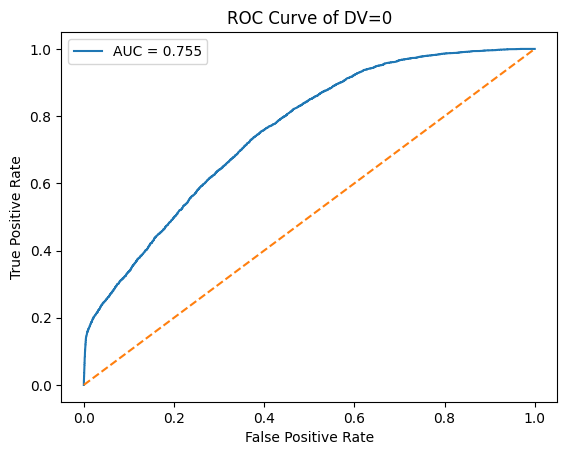

              precision    recall  f1-score   support

           0       0.81      0.15      0.25      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.86     30000
   macro avg       0.84      0.57      0.59     30000
weighted avg       0.85      0.86      0.81     30000

current model auc:0.754689
current model name:base


In [42]:
model_summary(baseline_pipeline, X_val_fe, y_val, "base")

## -----------------------------------------------------------

In [43]:


def recall_threshold_with_min_precision(fitted_model, X_val, y_val, min_precision=0.40):

    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]
    thresholds = np.linspace(0.01, 0.99, 100)

    best_threshold = None
    best_recall = -1

    for t in thresholds:
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        precision = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
        recall = recall_score(y_val, y_pred, pos_label=0, zero_division=0)

        if precision >= min_precision and recall > best_recall:
            best_recall = recall
            best_threshold = t

    if best_threshold is None:
        print(f"No threshold found with class 0 precision >= {min_precision}")
        return None

    print(f"Best threshold for class 0 recall with precision >= {min_precision}: {best_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= best_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return best_threshold

In [44]:
recall_threshold_with_min_precision(baseline_pipeline, X_val_fe, y_val)

Best threshold for class 0 recall with precision >= 0.4: 0.24757575757575756
Classification report with threshold
              precision    recall  f1-score   support

           0       0.40      0.33      0.36      4822
           1       0.88      0.91      0.89     25178

    accuracy                           0.81     30000
   macro avg       0.64      0.62      0.63     30000
weighted avg       0.80      0.81      0.81     30000



np.float64(0.24757575757575756)

## Pipeline name extraction

## Slightly more complex model selection

In [45]:
from sklearn.metrics import make_scorer, f1_score

#to make a score that is f1, score but to detect it on the minority cl asss 0
f1_class_0 = make_scorer(f1_score, pos_label=0)

In [46]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [47]:
pipe = Pipeline([
    ("preprocess", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=300, random_state=42),
        threshold="mean"
    )),
    ("sampler", "passthrough"),
    ("model", LogisticRegression(max_iter=1000))
])

In [48]:
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()

n_class_0, n_class_1
scale_pos_weight = n_class_0 / n_class_1

In [51]:
param_XGB_sampler = [
    #Note to self 5/11: try with smote
    #Each dictionary value is for each model set up, like for example each differnt versions of Logistic regression are based on the different model penalties, and not all can use other model penalties
    

    # XGBoost
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "sampler": [
    
    # Undersampling
    # RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.40, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.50, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.70, random_state=42),

    # Oversampling
    # RandomOverSampler(sampling_strategy=0.25, random_state=42),
    # RandomOverSampler(sampling_strategy=0.35, random_state=42),
    # RandomOverSampler(sampling_strategy=0.50, random_state=42),

    
    # SMOTE
    SMOTE(sampling_strategy=0.25, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),

    SMOTE(sampling_strategy=0.25, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),

    SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42)
],
        'model': [XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )],
        'model__n_estimators': [100, 300, 500,800],
        'model__learning_rate': [0.01, 0.05, 0.1],
        "model__booster": ["gbtree"], #removed "dart"
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        # Regularization
        'model__reg_alpha': [0, 0.01, 0.1, 1],
        'model__reg_lambda': [1, 5, 10]
    }
]

In [52]:
XGB_sampler_model_smoted = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_XGB_sampler,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

XGB_sampler_model_smoted.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


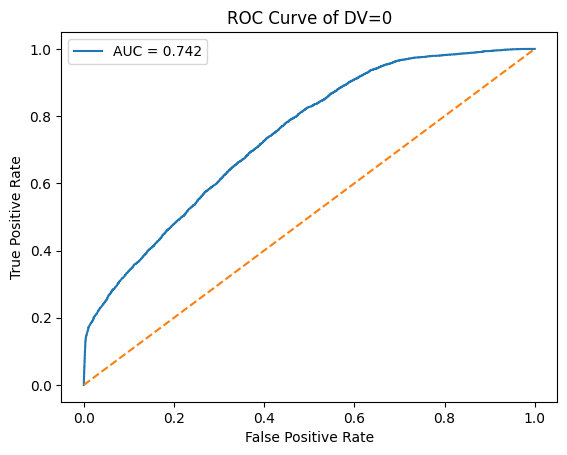

              precision    recall  f1-score   support

           0       0.77      0.16      0.27      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.86     30000
   macro avg       0.82      0.58      0.60     30000
weighted avg       0.85      0.86      0.82     30000

current model auc:0.741868
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.23232323232323235
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.57      0.38      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.59      0.65      0.60     30000
weighted avg       0.80      0.71      0.74     30000

0.23232323232323235
Youden threshold for class 0: 0.17228400707244873
Classification report with threshold
              precision    recall  f1-score   support

           0     

In [53]:
print(model_summary(XGB_sampler_model_smoted, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(XGB_sampler_model_smoted,X_val_fe,y_val))
print(Youden_threshold(XGB_sampler_model_smoted,X_val_fe,y_val))

In [54]:
best_XGB_sampler_model = XGB_sampler_model_smoted.best_estimator_

In [55]:
joblib.dump(best_XGB_sampler_model, "best_XGB_sampler_model_smoted.pkl")

['best_XGB_sampler_model_smoted.pkl']

In [170]:
loaded_model = joblib.load("best_XGB_sampler_model.pkl")

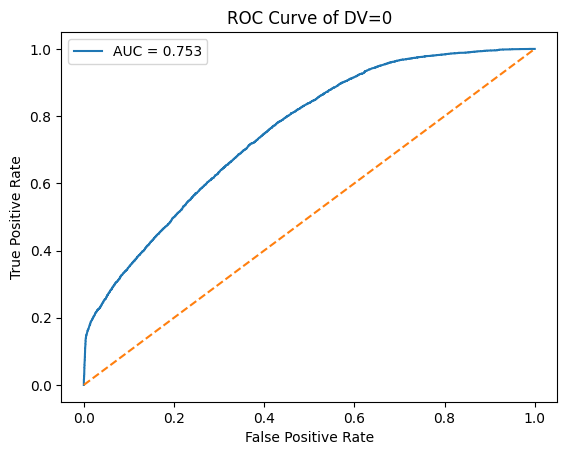

              precision    recall  f1-score   support

           0       0.33      0.47      0.39      4822
           1       0.89      0.82      0.85     25178

    accuracy                           0.76     30000
   macro avg       0.61      0.64      0.62     30000
weighted avg       0.80      0.76      0.78     30000

current model auc:0.752787
current model name:Best Random Search Model
None


In [171]:
print(model_summary(loaded_model, X_val_fe, y_val, "Best Random Search Model"))

In [172]:
XGB_param_no_sampler = [

    # XGBoost
    {
    "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
    "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

    "sampler": ["passthrough"],

    "model": [
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ],

    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__booster": ["gbtree"],#"dart"

    "model__scale_pos_weight": [scale_pos_weight, 5, 10, 20],

    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}
]

In [177]:
XGB_no_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=XGB_param_no_sampler,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

XGB_no_sampler_model.fit(X_train_fe, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [178]:
joblib.dump(XGB_no_sampler_model, "XGB_no_sampler_model.pkl")

['XGB_no_sampler_model.pkl']

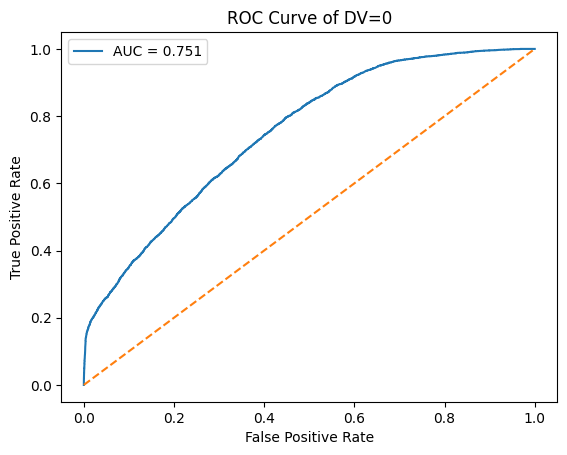

              precision    recall  f1-score   support

           0       0.92      0.04      0.08      4822
           1       0.85      1.00      0.92     25178

    accuracy                           0.85     30000
   macro avg       0.88      0.52      0.50     30000
weighted avg       0.86      0.85      0.78     30000

current model auc:0.750829
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.020202020202020204
Classification report with threshold
              precision    recall  f1-score   support

           0       0.27      0.68      0.39      4822
           1       0.91      0.66      0.76     25178

    accuracy                           0.66     30000
   macro avg       0.59      0.67      0.58     30000
weighted avg       0.81      0.66      0.70     30000

0.020202020202020204
Youden threshold for class 0: 0.017164766788482666
Classification report with threshold
              precision    recall  f1-score   support

           0  

In [179]:
print(model_summary(XGB_no_sampler_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(XGB_no_sampler_model,X_val_fe,y_val))
print(Youden_threshold(XGB_no_sampler_model,X_val_fe,y_val))

In [182]:
XGB_param_mixed = [

    # XGBoost
    {
    "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
    "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

    "sampler": [
    # Undersampling
    RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    RandomUnderSampler(sampling_strategy=0.40, random_state=42),
    RandomUnderSampler(sampling_strategy=0.50, random_state=42),
    RandomUnderSampler(sampling_strategy=0.70, random_state=42),

    # Oversampling
    RandomOverSampler(sampling_strategy=0.25, random_state=42),
    RandomOverSampler(sampling_strategy=0.35, random_state=42),
    RandomOverSampler(sampling_strategy=0.50, random_state=42),

    # SMOTE
    SMOTE(sampling_strategy=0.25, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),

    SMOTE(sampling_strategy=0.25, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),

    SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
],

    "model": [
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            objective="binary:logistic"
        )
    ],

    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__booster": ["gbtree"],#"dart"

    "model__scale_pos_weight": [scale_pos_weight, 5, 10, 20],

    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}
]

In [183]:
XGB_mixed_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=XGB_param_mixed,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

XGB_mixed_model.fit(X_train_fe, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [184]:
joblib.dump(XGB_mixed_model, "XGB_mixed_model.pkl")

['XGB_mixed_model.pkl']

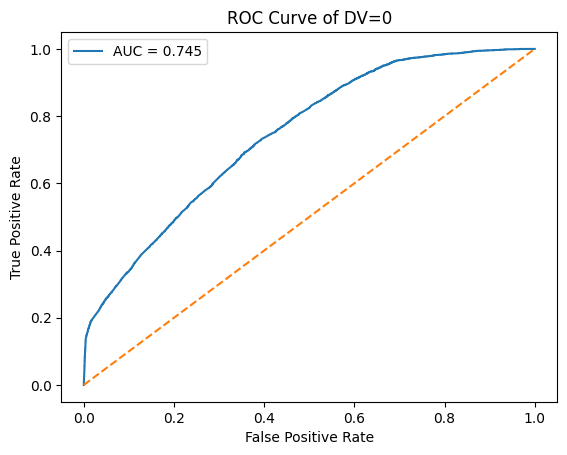

              precision    recall  f1-score   support

           0       0.21      0.96      0.35      4822
           1       0.98      0.32      0.48     25178

    accuracy                           0.42     30000
   macro avg       0.59      0.64      0.41     30000
weighted avg       0.85      0.42      0.46     30000

current model auc:0.745166
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.6565656565656566
Classification report with threshold
              precision    recall  f1-score   support

           0       0.27      0.68      0.39      4822
           1       0.91      0.65      0.76     25178

    accuracy                           0.66     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.81      0.66      0.70     30000

0.6565656565656566
Youden threshold for class 0: 0.6445636749267578
Classification report with threshold
              precision    recall  f1-score   support

           0       0

In [185]:
print(model_summary(XGB_mixed_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(XGB_mixed_model,X_val_fe,y_val))
print(Youden_threshold(XGB_mixed_model,X_val_fe,y_val))

In [187]:
param_dist_random_forest = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            RandomOverSampler(sampling_strategy=0.35, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),

            SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [RandomForestClassifier(random_state=42, n_jobs=-1)],

        "model__n_estimators": [300, 500, 800,1000],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2"],
        "model__criterion": ["gini", "entropy"],

        "model__class_weight": ["balanced", {0: 2, 1: 1},
    {0: 3, 1: 1},
    {0: 5, 1: 1}],

        "model__bootstrap": [True, False],
    }
]

In [189]:
rf_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist_random_forest,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_model.fit(X_train_fe, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [RandomForestC...ndom_state=42)], 'model__bootstrap': [True, False], 'model__class_weight': ['balanced', {0: 2, 1: 1}, ...], 'model__criterion': ['gini', 'entropy'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [190]:
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

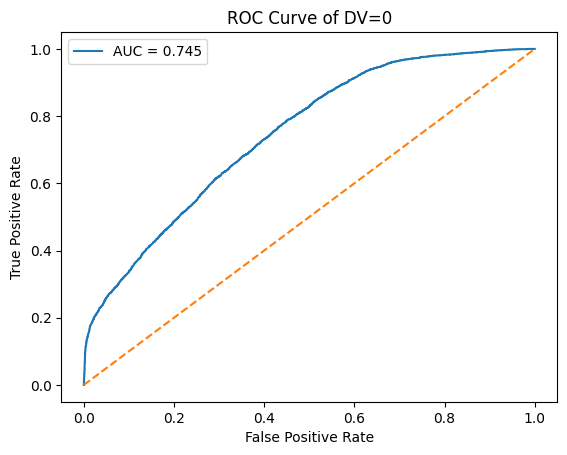

              precision    recall  f1-score   support

           0       0.28      0.62      0.39      4822
           1       0.91      0.70      0.79     25178

    accuracy                           0.69     30000
   macro avg       0.59      0.66      0.59     30000
weighted avg       0.81      0.69      0.73     30000

current model auc:0.745237
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5050505050505051
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.61      0.39      4822
           1       0.90      0.71      0.80     25178

    accuracy                           0.69     30000
   macro avg       0.60      0.66      0.59     30000
weighted avg       0.81      0.69      0.73     30000

0.5050505050505051
Youden threshold for class 0: 0.43733279205670217
Classification report with threshold
              precision    recall  f1-score   support

           0       

In [191]:
print(model_summary(rf_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(rf_model,X_val_fe,y_val))
print(Youden_threshold(rf_model,X_val_fe,y_val))

In [192]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    sampling_strategy="auto",
    replacement=False,
    random_state=42,
    n_jobs=-1
)

In [194]:

param_bagging = [
    {
        "model": [
            BalancedBaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=1
            )
        ],

        # Stronger imbalance handling
        "model__sampling_strategy": ["auto", 0.3, 0.5, 0.7, 1.0],
        "model__replacement": [True, False],

        # More trees = more stable
        "model__n_estimators": [100, 300, 500,800],

        # Control tree overfitting
        "model__estimator__max_depth": [3, 5, 10, 20, None],
        "model__estimator__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__estimator__min_samples_split": [2, 5, 10, 20],

        # Extra imbalance pressure inside each tree
        "model__estimator__class_weight": ["balanced"],

        # Randomness / diversity
        "model__max_samples": [0.5, 0.75, 1.0],
        "model__max_features": [0.5, 0.75, 1.0]
    }
]

In [196]:
bagging_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_bagging,
    n_iter=5,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

bagging_search.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [BalancedBaggi...ndom_state=42)], 'model__estimator__class_weight': ['balanced'], 'model__estimator__max_depth': [3, 5, ...], 'model__estimator__min_samples_leaf': [1, 2, ...], ...}]"
,n_iter,5
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [197]:
joblib.dump(bagging_search, "bagging_search_model.pkl")

['bagging_search_model.pkl']

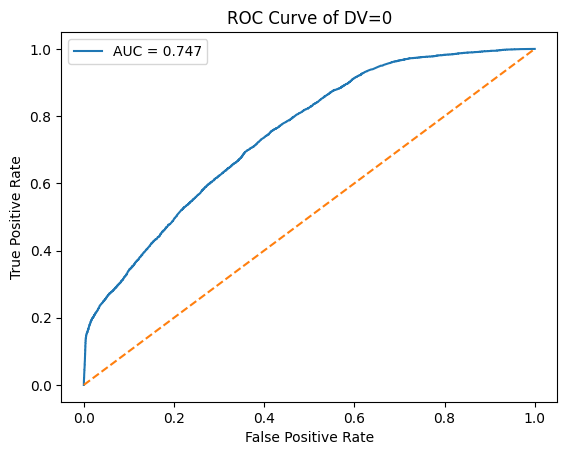

              precision    recall  f1-score   support

           0       0.26      0.76      0.38      4822
           1       0.93      0.58      0.71     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000

current model auc:0.746726
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5555555555555556
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.58      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.80      0.71      0.74     30000

0.5555555555555556
Youden threshold for class 0: 0.5028879772402
Classification report with threshold
              precision    recall  f1-score   support

           0       0.26

In [198]:
print(model_summary(bagging_search, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(bagging_search,X_val_fe,y_val))
print(Youden_threshold(bagging_search,X_val_fe,y_val))

## Pipeline name extraction

In [200]:
lr_l2_sampler_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            # No sampler baseline inside sampler search
            "passthrough",

            # Undersampling majority class
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            # Oversampling minority class 0
            RandomOverSampler(sampling_strategy=0.30, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),
            RandomOverSampler(sampling_strategy=0.70, random_state=42),

            # SMOTE versions
            SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=3, random_state=42),

            SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "saga"],
        "model__class_weight": [None],
        "model__tol": [1e-4, 1e-3]
    }
]

In [201]:
lr_l2_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l2_sampler_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

lr_l2_sampler_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__penalty': ['l2'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [202]:
joblib.dump(lr_l2_sampler_model, "lr_l2_sampler_model.pkl")

['lr_l2_sampler_model.pkl']

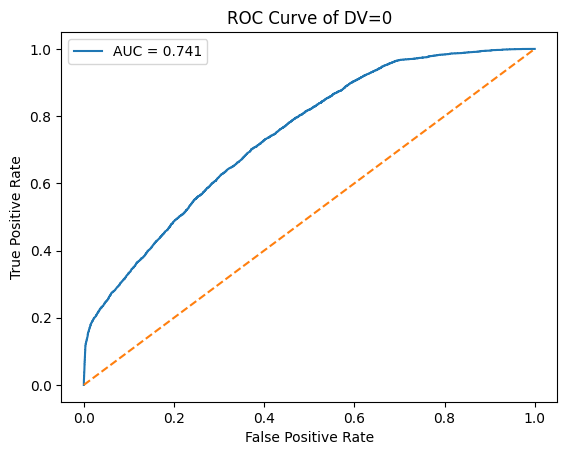

              precision    recall  f1-score   support

           0       0.47      0.26      0.34      4822
           1       0.87      0.94      0.90     25178

    accuracy                           0.83     30000
   macro avg       0.67      0.60      0.62     30000
weighted avg       0.81      0.83      0.81     30000

current model auc:0.741500
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.393939393939394
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.55      0.39      4822
           1       0.90      0.76      0.82     25178

    accuracy                           0.72     30000
   macro avg       0.60      0.65      0.60     30000
weighted avg       0.80      0.72      0.75     30000

0.393939393939394
Youden threshold for class 0: 0.3479621836953173
Classification report with threshold
              precision    recall  f1-score   support

           0       0.2

In [203]:
print(model_summary(lr_l2_sampler_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l2_sampler_model,X_val_fe,y_val))
print(Youden_threshold(lr_l2_sampler_model,X_val_fe,y_val))

In [205]:
lr_l1_sampler_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            "passthrough",

            # Undersampling majority class
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            # Oversampling minority class 0
            RandomOverSampler(sampling_strategy=0.30, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),
            RandomOverSampler(sampling_strategy=0.70, random_state=42),

            # SMOTE versions
            SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=3, random_state=42),

            SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"],
        "model__class_weight": [None],
        "model__tol": [1e-4, 1e-3]
    }
]

In [206]:
lr_l1_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l1_sampler_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l1_sampler_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__penalty': ['l1'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [207]:
joblib.dump(lr_l1_sampler_model, "lr_l1_sampler_model.pkl")

['lr_l1_sampler_model.pkl']

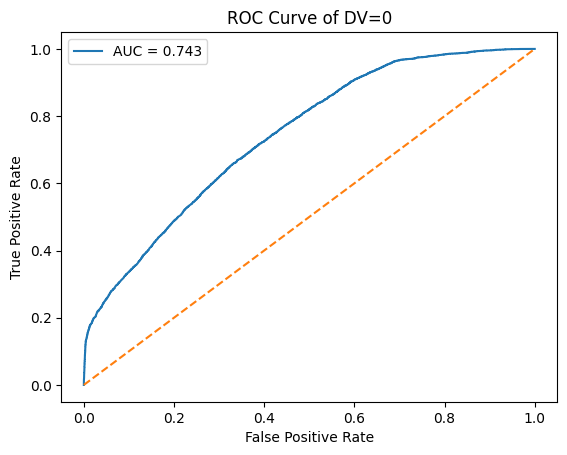

              precision    recall  f1-score   support

           0       0.32      0.48      0.38      4822
           1       0.89      0.80      0.85     25178

    accuracy                           0.75     30000
   macro avg       0.61      0.64      0.62     30000
weighted avg       0.80      0.75      0.77     30000

current model auc:0.742851
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.4747474747474748
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.57      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.65      0.60     30000
weighted avg       0.80      0.71      0.74     30000

0.4747474747474748
Youden threshold for class 0: 0.4449829114864826
Classification report with threshold
              precision    recall  f1-score   support

           0       0

In [208]:
print(model_summary(lr_l1_sampler_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l1_sampler_model,X_val_fe,y_val))
print(Youden_threshold(lr_l1_sampler_model,X_val_fe,y_val))

In [211]:
lr_l2_weights_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": ["passthrough"],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],

        # lbfgs is usually faster; saga is okay to compare
        "model__solver": ["lbfgs", "saga"],

        # class 0 is your minority, so these weights focus more on class 0
        "model__class_weight": [
            None,
            "balanced",
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ],

        "model__tol": [1e-4, 1e-3]
    }
]

In [212]:
lr_l2_weights_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l2_weights_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l2_weights_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l2'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [213]:
joblib.dump(lr_l2_weights_model, "lr_l2_weights_model.pkl")

['lr_l2_weights_model.pkl']

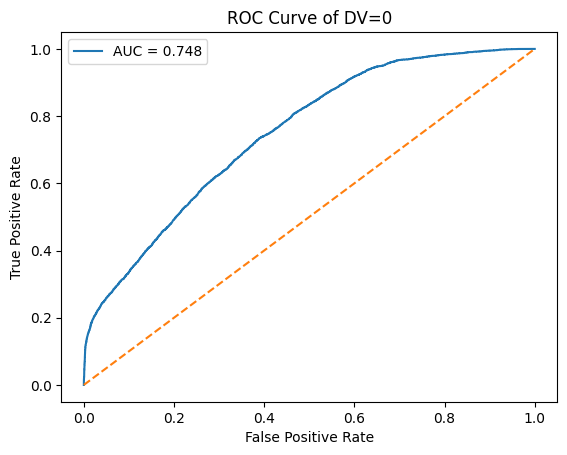

              precision    recall  f1-score   support

           0       0.27      0.72      0.39      4822
           1       0.92      0.62      0.74     25178

    accuracy                           0.64     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.82      0.64      0.69     30000

current model auc:0.748405
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5353535353535354
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.60      0.40      4822
           1       0.90      0.72      0.80     25178

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.74     30000

0.5353535353535354
Youden threshold for class 0: 0.4953861270581327
Classification report with threshold
              precision    recall  f1-score   support

           0       0

In [214]:
print(model_summary(lr_l2_weights_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l2_weights_model,X_val_fe,y_val))
print(Youden_threshold(lr_l2_weights_model,X_val_fe,y_val))

In [225]:
lr_l1_weights_param = [
    # --------------------------------------------------
    # 4. Logistic Regression - L1 with no sampler + class weights
    # --------------------------------------------------
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": ["passthrough"],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"],

        "model__class_weight": [
            None,
            "balanced",
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ],

        "model__tol": [1e-4, 1e-3]
    }
]

In [227]:
lr_l1_weights_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l1_weights_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l1_weights_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l1'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [228]:
joblib.dump(lr_l1_weights_model, "lr_l1_weights_model.pkl")

['lr_l1_weights_model.pkl']

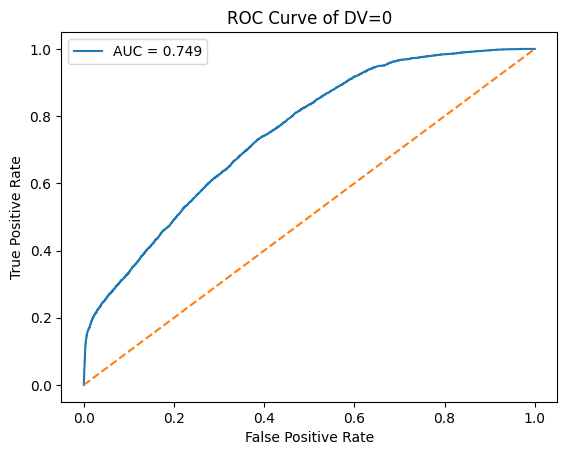

              precision    recall  f1-score   support

           0       0.27      0.72      0.39      4822
           1       0.92      0.63      0.75     25178

    accuracy                           0.64     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.82      0.64      0.69     30000

current model auc:0.748654
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5353535353535354
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.60      0.39      4822
           1       0.90      0.72      0.80     25178

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.74     30000

0.5353535353535354
Youden threshold for class 0: 0.49593943162193943
Classification report with threshold
              precision    recall  f1-score   support

           0       

In [229]:
print(model_summary(lr_l1_weights_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l1_weights_model,X_val_fe,y_val))
print(Youden_threshold(lr_l1_weights_model,X_val_fe,y_val))

In [122]:
from torch.optim import Adam
from skorch import NeuralNetClassifier

In [123]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [124]:
from skorch.callbacks import EarlyStopping

In [125]:
class MLPClassifier_largeNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
#Start with a dense layer to capture information and then decrease to local features
        self.network = nn.Sequential(
            nn.LazyLinear(256),


            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(16, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [126]:
class_weights = torch.tensor([3.0, 1.0], dtype=torch.float32).to(device)

In [127]:
net = NeuralNetClassifier(
    module=MLPClassifier_largeNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=100,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [129]:
nn_pipe = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net)
])

In [63]:
nn_pipe.fit(X_train_fe, y_train)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5552       0.7566        0.5191  5.0846
      2        0.5274       0.7577        0.5154  4.8683
      3        0.5259       0.7908        0.5123  3.6681
      4        0.5247       0.8042        0.5141  5.2797
      5        0.5243       0.8444        0.5183  8.8200
      6        0.5238       0.8044        0.5116  11.4445
      7        0.5221       0.8047        0.5155  13.2514
      8        0.5215       0.8213        0.5135  14.2532
      9        0.5211       0.8295        0.5121  14.6814
     10        0.5216       0.8134        0.5096  14.9265
     11        0.5210       0.8034        0.5087  15.1010
     12        0.5209       0.8017        0.5089  15.2454
     13        0.5220       0.8075        0.5088  15.8580
     14        0.5191       0.8334        0.5130  15.5044
     15        0.5199       0.8157        0.5110  15.2507
     16        0.5206

,steps,"[('preprocess', ...), ('to_float32', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for forma

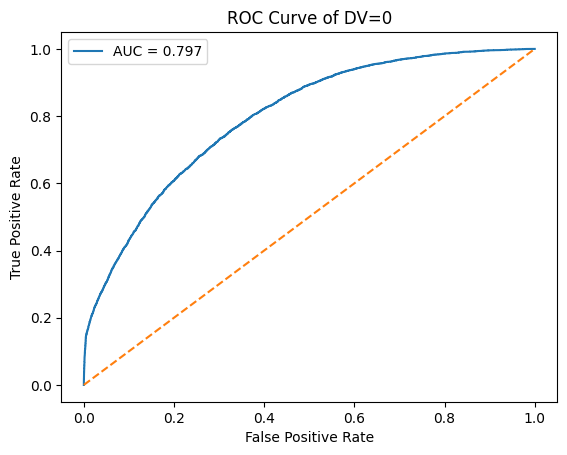

              precision    recall  f1-score   support

           0       0.43      0.49      0.45      4822
           1       0.90      0.87      0.89     25178

    accuracy                           0.81     30000
   macro avg       0.66      0.68      0.67     30000
weighted avg       0.82      0.81      0.82     30000

current model auc:0.797182
current model name:a


In [64]:
model_summary(nn_pipe, X_val_fe, y_val, "a")

In [65]:
f1_threshold(nn_pipe,X_val_fe, y_val)

F1 optimal threshold for class 0: 0.4747474747474748
Classification report with threshold
              precision    recall  f1-score   support

           0       0.39      0.57      0.46      4822
           1       0.91      0.83      0.87     25178

    accuracy                           0.79     30000
   macro avg       0.65      0.70      0.66     30000
weighted avg       0.83      0.79      0.80     30000



np.float64(0.4747474747474748)

In [130]:
from scipy.stats import loguniform, uniform

In [131]:
param_dist_nn = {
    # learning rate
    "model__optimizer__lr": loguniform(1e-4, 1e-2),

    # regularization
    "model__optimizer__weight_decay": loguniform(1e-5, 1e-1),

    # dropout: tries values from 0.10 to 0.50
    "model__module__dropout": uniform(0.1, 0.4),

    # batch size
    "model__batch_size": [128, 256, 512],

    # optimizer
    "model__optimizer": [
        torch.optim.Adam,
        torch.optim.AdamW
    ],

    # class imbalance weights
    # order is [class_0_weight, class_1_weight]
    "model__criterion__weight": [
        torch.tensor([1.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([2.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([3.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([5.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([10.0, 1.0], dtype=torch.float32).to(device),
    ]
}

In [ ]:




random_search_Lnn = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist_nn,
    n_iter=15,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_Lnn.fit(X_train_fe, y_train.astype("int64"))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6229       0.6634        0.5716  2.2336
      2        0.5856       0.6616        0.5619  2.2673
      3        0.5796       0.6857        0.5545  2.3722
      4        0.5780       0.7088        0.5522  2.2647
      5        0.5731       0.6737        0.5534  2.2377
      6        0.5723       0.6413        0.5602  2.2625
      7        0.5737       0.6798        0.5566  2.2019
      8        0.5718       0.6353        0.5609  2.1162
      9        0.5743       0.7000        0.5550  2.2990
     10        0.5751       0.7196        0.5512  2.9872
     11        0.5748       0.6377        0.5519  2.4371
     12        0.5731       0.6853        0.5522  5.1340
     13        0.5705       0.6970        0.5537  6.5037
     14        0.5717       0.7021        0.5514  7.6247
     15        0.5727      

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tart=False))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....00283A94A82D0>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `

In [67]:
class MLPClassifier_smallNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()

        self.network = nn.Sequential(
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [60]:
class MLPClassifier_mediumNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()

        self.network = nn.Sequential(
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [61]:
net_med = NeuralNetClassifier(
    module=MLPClassifier_mediumNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=50,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [68]:
net_smol = NeuralNetClassifier(
    module=MLPClassifier_smallNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=50,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [62]:
nn_pipe_med = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net_med)
])

In [69]:
nn_pipe_smol = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net_smol)
])

In [63]:
random_search_Mnn = RandomizedSearchCV(
    estimator=nn_pipe_med,
    param_distributions=param_dist_nn,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_Mnn.fit(X_train_fe, y_train.astype("int64"))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5898       0.6346        0.5531  1.9087
      2        0.5649       0.6665        0.5515  1.8165
      3        0.5630       0.7102        0.5503  2.0447
      4        0.5630       0.7310        0.5475  1.9648
      5        0.5624       0.7422        0.5533  2.4333
      6        0.5615       0.5940        0.5556  1.8898
      7        0.5622       0.6574        0.5486  1.8885
      8        0.5614       0.6632        0.5487  1.9561
      9        0.5625       0.6938        0.5490  1.9353
     10        0.5597       0.7287        0.5510  1.9607
     11        0.5607       0.6726        0.5475  1.8555
     12        0.5609       0.7191        0.5478  2.0596
     13        0.5594       0.7011        0.5493  1.8815
Stopping since valid_loss has not improved in the last 10 epochs.
[CV] END model__ba

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....00180A10B0050>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [70]:
random_search_smol = RandomizedSearchCV(
    estimator=nn_pipe_smol,
    param_distributions=param_dist_nn,
    n_iter=15,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_smol.fit(X_train_fe, y_train.astype("int64"))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5942       0.6927        0.5488  1.5124
      2        0.5614       0.7003        0.5487  1.5093
      3        0.5601       0.6726        0.5473  1.6630
      4        0.5602       0.7061        0.5495  1.5597
      5        0.5593       0.6301        0.5511  1.6549
      6        0.5593       0.6563        0.5489  1.6776
      7        0.5593       0.7147        0.5519  1.5430
      8        0.5578       0.6607        0.5508  2.0177
      9        0.5599       0.7128        0.5519  2.0073
     10        0.5595       0.7045        0.5474  1.5456
     11        0.5584       0.6465        0.5488  1.7619
     12        0.5560       0.6896        0.5458  1.6193
     13        0.5578       0.6648        0.5458  1.5848
     14        0.5569       0.6756        0.5471  1.6009
     15        0.5570      

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....00180A10B0050>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,15
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [73]:
# Best hyperparameters found by RandomizedSearchCV
random_search_Lnn.best_params_

{'model__batch_size': 256,
 'model__criterion__weight': tensor([3., 1.]),
 'model__module__dropout': np.float64(0.2529847965068651),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.0015304852121831463),
 'model__optimizer__weight_decay': np.float64(1.5339162591163613e-05)}

In [65]:
random_search_Mnn.best_params_

{'model__batch_size': 512,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.29807076404450805),
 'model__optimizer': torch.optim.adam.Adam,
 'model__optimizer__lr': np.float64(0.00022219245475399164),
 'model__optimizer__weight_decay': np.float64(0.0003666421832063722)}

In [71]:

random_search_smol.best_params_

{'model__batch_size': 256,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.2246844304357644),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.00026054534945804014),
 'model__optimizer__weight_decay': np.float64(0.0018655260217376823)}

# Best params for large NN:
'model__batch_size': 256,
 'model__criterion__weight': tensor([3., 1.]),
 'model__module__dropout': np.float64(0.2529847965068651),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.0015304852121831463),
 'model__optimizer__weight_decay': np.float64(1.5339162591163613e-05)}


 ## Best params for medium NN:
 {'model__batch_size': 512,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.29807076404450805),
 'model__optimizer': torch.optim.adam.Adam,
 'model__optimizer__lr': np.float64(0.00022219245475399164),
 'model__optimizer__weight_decay': np.float64(0.0003666421832063722)}


 ## Best params for small NN:
 {'model__batch_size': 256,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.2246844304357644),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.00026054534945804014),
 'model__optimizer__weight_decay': np.float64(0.0018655260217376823)}

In [70]:
best_model = random_search_Lnn.best_estimator_

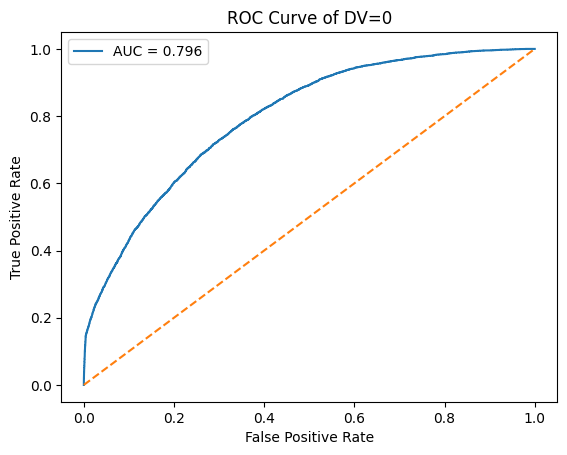

              precision    recall  f1-score   support

           0       0.32      0.73      0.44      4822
           1       0.93      0.70      0.80     25178

    accuracy                           0.71     30000
   macro avg       0.62      0.71      0.62     30000
weighted avg       0.83      0.71      0.74     30000

current model auc:0.796471
current model name:Best Random Search Model


In [72]:
model_summary(random_search_smol, X_val_fe, y_val, "Best Random Search Model")

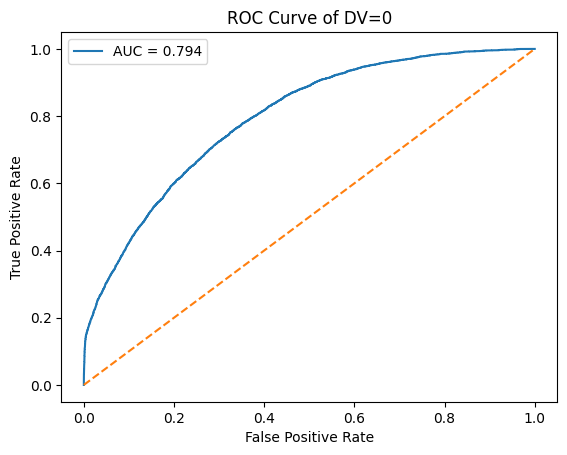

              precision    recall  f1-score   support

           0       0.39      0.54      0.45      4822
           1       0.90      0.84      0.87     25178

    accuracy                           0.79     30000
   macro avg       0.65      0.69      0.66     30000
weighted avg       0.82      0.79      0.80     30000

current model auc:0.794141
current model name:Best Random Search Model


In [68]:
model_summary(best_model, X_val_fe, y_val, "Best Random Search Model")

“Given the borrower and loan information available now, can we classify whether the loan is currently in good standing or risky?”

## ------------------------